# 03 — Phase 3: Target Engineering


## 1 — Bootstrap


In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

CWD = Path.cwd()
ROOT = CWD.parent if CWD.name == 'notebooks' else CWD
SRC = ROOT / 'src'
assert SRC.exists(), f'Could not find src/ at {SRC}'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

import config
from dataset import build_dataset
from stationary import add_stationary_features, get_stationary_features
from evaluation import walk_forward_evaluate
from targets import (build_directional_dataset, compare_targets,
                     forward_return, target_autocorrelation,
                     threshold_target, volatility_scaled_target)
from abstention import (abstention_report, brier_score, calibration_table,
                        calibrate_probabilities, coverage_accuracy_curve,
                        evaluate_with_abstention)

pd.set_option('display.width', 140)
plt.rcParams['figure.dpi'] = 110

def rf(n=500, leaf=20):
    return RandomForestClassifier(n_estimators=n, min_samples_leaf=leaf,
                                  random_state=config.RANDOM_STATE, n_jobs=-1)

BASE = {}
for key in config.list_stocks():
    d = build_dataset(key, with_sentiment=False, save=False, verbose=False)
    BASE[key] = add_stationary_features(d).dropna().reset_index(drop=True)
    print(f'{key:10s} {len(BASE[key]):5d} rows')

FEATURES = get_stationary_features(BASE['TCS'])
print(f'\nStationary features: {len(FEATURES)}')


RELIANCE     383 rows
TCS         2354 rows

Stationary features: 52


## 2 — The size of the moves being labelled


In [2]:
d = BASE['TCS']
fwd = forward_return(d, 1).dropna()

bands = {
    'under 0.25%': (fwd.abs() < 0.0025).mean(),
    '0.25% - 0.5%': ((fwd.abs() >= 0.0025) & (fwd.abs() < 0.005)).mean(),
    '0.5% - 1.0%': ((fwd.abs() >= 0.005) & (fwd.abs() < 0.010)).mean(),
    '1.0% - 2.0%': ((fwd.abs() >= 0.010) & (fwd.abs() < 0.020)).mean(),
    'over 2.0%': (fwd.abs() >= 0.020).mean(),
}

band_df = pd.DataFrame({'share_of_days': pd.Series(bands).round(4)})
band_df['cumulative'] = band_df['share_of_days'].cumsum().round(4)
print(band_df.to_string())
print()
print(f'Median absolute daily move : {fwd.abs().median():.4%}')
print(f'Days moving under 0.5%     : {(fwd.abs() < 0.005).mean():.1%}')


              share_of_days  cumulative
under 0.25%          0.1764      0.1764
0.25% - 0.5%         0.1768      0.3532
0.5% - 1.0%          0.2359      0.5891
1.0% - 2.0%          0.2635      0.8526
over 2.0%            0.1475      1.0001

Median absolute daily move : 0.7857%
Days moving under 0.5%     : 35.3%


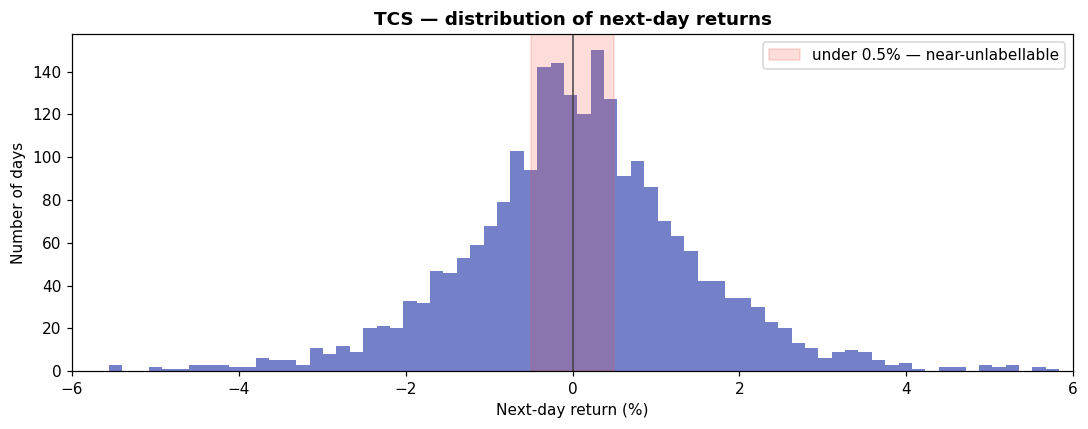

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(fwd * 100, bins=120, color='#5C6BC0', alpha=0.85)
ax.axvspan(-0.5, 0.5, color='#F44336', alpha=0.18,
           label='under 0.5% — near-unlabellable')
ax.axvline(0, color='#424242', lw=1)
ax.set_xlim(-6, 6)
ax.set_xlabel('Next-day return (%)')
ax.set_ylabel('Number of days')
ax.set_title('TCS — distribution of next-day returns', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'return_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 3 — Comparing target definitions


In [4]:
specs = {
    'binary 1d (Phase 1/2)': lambda x: threshold_target(x, 1, 0.0),
    'fixed 0.5% 1d': lambda x: threshold_target(x, 1, 0.005),
    'fixed 1.0% 1d': lambda x: threshold_target(x, 1, 0.010),
    'vol-scaled k=0.5 1d': lambda x: volatility_scaled_target(x, 1, 0.5),
    'vol-scaled k=1.0 1d': lambda x: volatility_scaled_target(x, 1, 1.0),
    'vol-scaled k=0.5 5d': lambda x: volatility_scaled_target(x, 5, 0.5),
}

for key in BASE:
    print(f'\n{key}')
    print(compare_targets(BASE[key], specs).to_string())



RELIANCE
                       n_labelled  pct_UP  pct_FLAT  pct_DOWN  coverage  up_share_of_moves  directional_majority  autocorr_lag1
target                                                                                                                         
binary 1d (Phase 1/2)         382  0.5183    0.0000    0.4817    1.0000             0.5183                0.5183         0.0486
fixed 0.5% 1d                 382  0.3246    0.3691    0.3063    0.6309             0.5145                0.5145         0.0203
fixed 1.0% 1d                 382  0.1754    0.6414    0.1832    0.3586             0.4891                0.5109         0.0805
vol-scaled k=0.5 1d           372  0.2930    0.4409    0.2661    0.5591             0.5240                0.5240         0.0376
vol-scaled k=1.0 1d           372  0.1586    0.6909    0.1505    0.3091             0.5130                0.5130         0.1042
vol-scaled k=0.5 5d           368  0.3560    0.3478    0.2962    0.6522             0.5458    

## 4 — Fixed vs volatility-scaled thresholds across stocks


In [5]:
rows = []
for key, d in BASE.items():
    fwd_k = forward_return(d, 1).dropna()
    rows.append({
        'stock': key,
        'median_abs_move': round(float(fwd_k.abs().median()), 5),
        'coverage_fixed_0.5%': round(float((fwd_k.abs() > 0.005).mean()), 4),
        'coverage_vol_k0.5': round(float(
            (volatility_scaled_target(d, 1, 0.5).dropna() != 0).mean()), 4),
    })

print(pd.DataFrame(rows).set_index('stock').to_string())


          median_abs_move  coverage_fixed_0.5%  coverage_vol_k0.5
stock                                                            
RELIANCE          0.00730               0.6309             0.5591
TCS               0.00786               0.6468             0.5570


## 5 — The overlapping-target trap


In [6]:
rows = []
for h in [1, 2, 3, 5, 10, 20]:
    overlap = build_directional_dataset(BASE['TCS'], horizon=h, k=0.5,
                                        non_overlapping=False)
    nonover = build_directional_dataset(BASE['TCS'], horizon=h, k=0.5,
                                        non_overlapping=True)
    rows.append({
        'horizon': h,
        'n_overlapping': len(overlap),
        'autocorr_overlapping': round(overlap['Target'].autocorr(1), 4),
        'n_nonoverlapping': len(nonover),
        'autocorr_nonoverlapping': round(nonover['Target'].autocorr(1), 4),
    })

overlap_df = pd.DataFrame(rows).set_index('horizon')
print(overlap_df.to_string())


         n_overlapping  autocorr_overlapping  n_nonoverlapping  autocorr_nonoverlapping
horizon                                                                                
1                 1305               -0.0261              1305                  -0.0261
2                 1343                0.3379               658                   0.0001
3                 1381                0.5023               469                  -0.0423
5                 1410                0.6767               274                  -0.0448
10                1465                0.8060               137                  -0.0443
20                1479                0.8984                75                  -0.3214


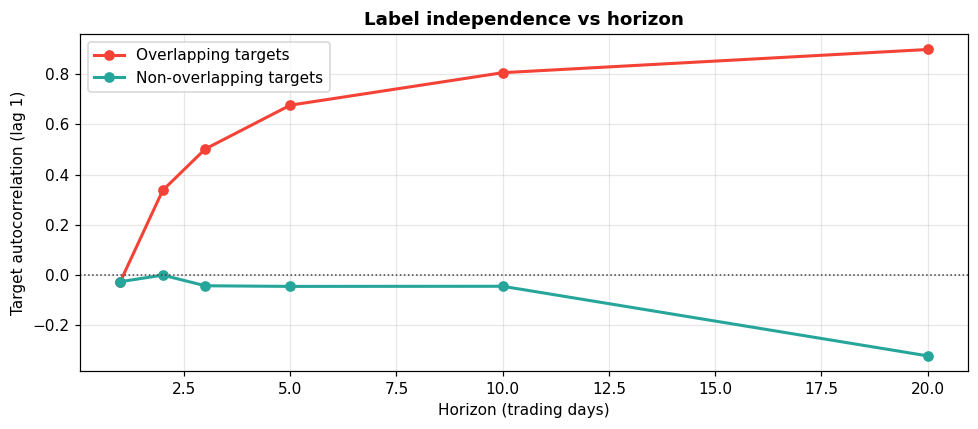

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(overlap_df.index, overlap_df['autocorr_overlapping'],
        'o-', color='#F44336', lw=2, label='Overlapping targets')
ax.plot(overlap_df.index, overlap_df['autocorr_nonoverlapping'],
        'o-', color='#26A69A', lw=2, label='Non-overlapping targets')
ax.axhline(0, color='#424242', lw=1, ls=':')
ax.set_xlabel('Horizon (trading days)')
ax.set_ylabel('Target autocorrelation (lag 1)')
ax.set_title('Label independence vs horizon', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'target_autocorrelation.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 6 — Persistence baseline inflation


In [8]:
rows = []
for h in [1, 3, 5, 10]:
    for nonov in [False, True]:
        d = build_directional_dataset(BASE['TCS'], horizon=h, k=0.5,
                                      non_overlapping=nonov)
        if len(d) < 200:
            continue
        r = walk_forward_evaluate(d, FEATURES, rf(), n_splits=5,
                                  embargo=max(52 // h, 5))
        b = r.baselines.mean()
        rows.append({
            'horizon': h,
            'non_overlapping': nonov,
            'n': len(d),
            'model': round(r.per_fold['accuracy'].mean(), 4),
            'majority': round(b['majority'], 4),
            'persistence': round(b['persistence'], 4),
        })

persist_df = pd.DataFrame(rows)
print(persist_df.to_string(index=False))


 horizon  non_overlapping    n  model  majority  persistence
       1            False 1305 0.5267    0.5298       0.4885
       1             True 1305 0.5267    0.5298       0.4885
       3            False 1381 0.5528    0.5529       0.7598
       3             True  469 0.5106    0.5404       0.4851
       5            False 1410 0.6000    0.5574       0.8298
       5             True  274 0.5193    0.5479       0.5425
      10            False 1465 0.5997    0.5934       0.9168


## 7 — Horizon and threshold sweep


In [9]:
sweep = []
for h in [1, 3, 5, 10]:
    for k in [0.0, 0.5, 1.0, 1.5]:
        d = build_directional_dataset(BASE['TCS'], horizon=h, k=k,
                                      non_overlapping=True)
        if len(d) < 200:
            continue
        try:
            r = walk_forward_evaluate(d, FEATURES, rf(), n_splits=5,
                                      embargo=max(52 // h, 5))
        except ValueError:
            continue
        s = r.summary()
        base = r.baselines.mean().max()
        sweep.append({
            'horizon': h,
            'k': k,
            'n': len(d),
            'accuracy': round(s['accuracy_mean'], 4),
            'std': round(s['accuracy_std'], 4),
            'best_baseline': round(base, 4),
            'edge': round(s['accuracy_mean'] - base, 4),
        })

sweep_df = pd.DataFrame(sweep)
print(sweep_df.to_string(index=False))
print()
print('Configurations whose edge exceeds their own fold std:')
print(sweep_df[sweep_df['edge'] > sweep_df['std']].to_string(index=False))


 horizon   k    n  accuracy    std  best_baseline    edge
       1 0.0 2340    0.5085 0.0191         0.5248 -0.0162
       1 0.5 1305    0.5267 0.0439         0.5298 -0.0031
       1 1.0  685    0.5302 0.0497         0.5512 -0.0210
       1 1.5  347    0.5653 0.1121         0.5542  0.0111
       3 0.0  780    0.5564 0.0172         0.5179  0.0385
       3 0.5  469    0.5106 0.0261         0.5404 -0.0298
       3 1.0  249    0.5200 0.0938         0.6000 -0.0800
       5 0.0  468    0.5765 0.0739         0.5565  0.0200
       5 0.5  274    0.5193 0.1007         0.5479 -0.0286
      10 0.0  234    0.5367 0.1015         0.5621 -0.0254

Configurations whose edge exceeds their own fold std:
 horizon   k   n  accuracy    std  best_baseline   edge
       3 0.0 780    0.5564 0.0172         0.5179 0.0385


## 8 — Confidence-gated prediction


In [10]:
CONFIG = dict(horizon=1, k=0.5, non_overlapping=True)

OOF = {}
for key, d in BASE.items():
    ds = build_directional_dataset(d, **CONFIG)
    emb = 52 if key == 'TCS' else 20
    r = walk_forward_evaluate(ds, FEATURES, rf(), n_splits=5, embargo=emb)
    OOF[key] = r
    print(f'{key}: {len(ds)} big-move rows of {len(d)} '
          f"({len(ds) / len(d):.0%} coverage), "
          f"overall acc {r.per_fold['accuracy'].mean():.4f}, "
          f'baseline {r.baselines.mean().max():.4f}')


RELIANCE: 208 big-move rows of 383 (54% coverage), overall acc 0.4183, baseline 0.5000
TCS: 1305 big-move rows of 2354 (55% coverage), overall acc 0.5267, baseline 0.5298


In [11]:
CURVES = {}
for key, r in OOF.items():
    curve = coverage_accuracy_curve(r.oof_predictions, min_samples=15)
    CURVES[key] = curve
    print(f'\n{key}')
    print(curve.to_string(index=False))



RELIANCE
 confidence_quantile  coverage  n_predictions  accuracy  subset_majority    edge  min_confidence
                 0.0    1.0000            104    0.4231           0.5769 -0.1538          0.0000
                 0.1    0.8942             93    0.4409           0.6022 -0.1613          0.0092
                 0.2    0.7981             83    0.4458           0.6145 -0.1687          0.0166
                 0.3    0.7019             73    0.4247           0.6164 -0.1918          0.0239
                 0.4    0.5962             62    0.4194           0.6774 -0.2581          0.0305
                 0.5    0.5000             52    0.4231           0.6538 -0.2308          0.0368
                 0.6    0.4038             42    0.3810           0.6429 -0.2619          0.0450
                 0.7    0.2981             31    0.4194           0.6452 -0.2258          0.0597
                 0.8    0.2019             21    0.4762           0.5714 -0.0952          0.0732

TCS
 confidence_qua

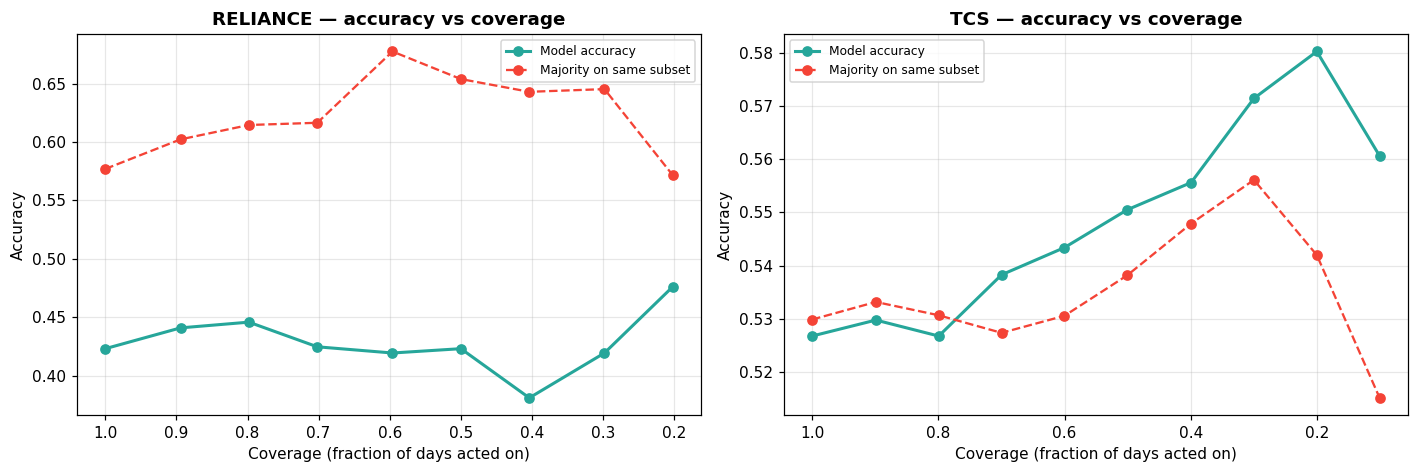

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

for ax, (key, curve) in zip(axes, CURVES.items()):
    ax.plot(curve['coverage'], curve['accuracy'], 'o-',
            color='#26A69A', lw=2, label='Model accuracy')
    ax.plot(curve['coverage'], curve['subset_majority'], 'o--',
            color='#F44336', lw=1.5, label='Majority on same subset')
    ax.set_xlabel('Coverage (fraction of days acted on)')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{key} — accuracy vs coverage', fontweight='bold')
    ax.invert_xaxis()
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(config.FIGURES_DIR / 'coverage_accuracy.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 9 — Probability calibration


In [13]:
for key, r in OOF.items():
    print(f'\n{key}')
    print(f'  Brier score (raw): {brier_score(r.oof_predictions)}'
          '   [0.25 = uninformative]')
    cal = calibrate_probabilities(r.oof_predictions)
    print(f'  Brier score (isotonic): '
          f"{brier_score(cal, proba_col='y_proba_calibrated')}")
    print(calibration_table(r.oof_predictions).to_string(index=False))



RELIANCE
  Brier score (raw): 0.2596   [0.25 = uninformative]
  Brier score (isotonic): 0.2806
           bin  n  mean_predicted  observed_frequency     gap
(0.365, 0.428] 21          0.4098              0.5714 -0.1616
(0.428, 0.465] 21          0.4479              0.7143 -0.2664
(0.465, 0.487] 20          0.4746              0.5500 -0.0754
(0.487, 0.518] 21          0.5010              0.4286  0.0724
(0.518, 0.594] 21          0.5428              0.6190 -0.0762

TCS
  Brier score (raw): 0.2496   [0.25 = uninformative]
  Brier score (isotonic): 0.2645
           bin   n  mean_predicted  observed_frequency     gap
(0.335, 0.471] 131          0.4323              0.4656 -0.0333
(0.471, 0.516] 130          0.4955              0.5462 -0.0506
(0.516, 0.555] 131          0.5355              0.5191  0.0164
(0.555, 0.591] 130          0.5728              0.5538  0.0190
(0.591, 0.726] 131          0.6247              0.5649  0.0598


## 10 — Operating point


In [14]:
points = []
for key, r in OOF.items():
    for thresh in [0.0, 0.03, 0.05, 0.08, 0.10, 0.12]:
        res = evaluate_with_abstention(r.oof_predictions,
                                       confidence_threshold=thresh)
        res['stock'] = key
        points.append(res)

points_df = pd.DataFrame(points)[
    ['stock', 'confidence_threshold', 'coverage', 'n_committed',
     'accuracy', 'subset_majority', 'edge']]
print(points_df.to_string(index=False))


   stock  confidence_threshold  coverage  n_committed  accuracy  subset_majority    edge
RELIANCE                  0.00    1.0000          104    0.4231           0.5769 -0.1538
RELIANCE                  0.03    0.6058           63    0.4286           0.6667 -0.2381
RELIANCE                  0.05    0.3654           38    0.3947           0.6579 -0.2632
RELIANCE                  0.08    0.1538           16    0.5000           0.5625 -0.0625
RELIANCE                  0.10    0.0192            2    0.0000           1.0000 -1.0000
RELIANCE                  0.12    0.0192            2    0.0000           1.0000 -1.0000
     TCS                  0.00    1.0000          653    0.5268           0.5299 -0.0031
     TCS                  0.03    0.7274          475    0.5453           0.5242  0.0211
     TCS                  0.05    0.5559          363    0.5427           0.5344  0.0083
     TCS                  0.08    0.3139          205    0.5659           0.5561  0.0098
     TCS             

## 11 — Save Phase 3 results


In [15]:
sweep_df.to_csv(config.REPORTS_DIR / 'phase3_sweep.csv', index=False)
overlap_df.to_csv(config.REPORTS_DIR / 'phase3_overlap.csv')
points_df.to_csv(config.REPORTS_DIR / 'phase3_operating_points.csv',
                 index=False)
for key, curve in CURVES.items():
    curve.to_csv(config.REPORTS_DIR / f'phase3_coverage_{key}.csv',
                 index=False)

summary = []
for key, r in OOF.items():
    curve = CURVES[key]
    best = curve.loc[curve['edge'].idxmax()]
    summary.append({
        'stock': key,
        'n_big_moves': int(curve.iloc[0]['n_predictions']),
        'full_coverage_accuracy': curve.iloc[0]['accuracy'],
        'full_coverage_edge': curve.iloc[0]['edge'],
        'best_coverage': best['coverage'],
        'best_accuracy': best['accuracy'],
        'best_edge': best['edge'],
        'brier': brier_score(r.oof_predictions),
    })

phase3 = pd.DataFrame(summary).set_index('stock')
phase3.to_csv(config.REPORTS_DIR / 'phase3_results.csv')
print('Saved to reports/')
print()
print(phase3.to_string())


Saved to reports/

          n_big_moves  full_coverage_accuracy  full_coverage_edge  best_coverage  best_accuracy  best_edge   brier
stock                                                                                                             
RELIANCE          104                  0.4231             -0.1538         0.2019         0.4762    -0.0952  0.2596
TCS               653                  0.5268             -0.0031         0.1011         0.5606     0.0455  0.2496
